# Research QuantBook: VIX-TermStructure (Short Volatility via Contango)

## Objectif
Reproduire l'analyse exploratoire de `research.ipynb` avec les données natives QuantConnect.

## Performance actuelle
- **Sharpe**: 0.051, **CAGR**: 3.6%, **MaxDD**: 35.2%
- **Signal**: VIX3M/VIX ratio > 1.05 (contango), VIX < 22, VIX < SMA10
- **Position**: 45% SVXY (-0.5x short vol)
- **Exit**: Trailing stop 10%, VIX spike > 28, backwardation (ratio < 1.02)

## Hypotheses a tester
1. Position size (30%, 45%, 60%)
2. VIX threshold (18, 22, 25, 30)
3. Contango depth (ratio 1.03, 1.05, 1.08)
4. Trailing stop (7%, 10%, 15%)
5. Cash allocation (SHY vs idle)

## Prerequis
- Environnement Lean Research
- Duree estimee: ~5 minutes

In [1]:
# Setup QuantBook (c.708 : HAS_QC gate for local-vs-QC-Cloud execution)
# [MOCK-aware] This notebook runs in two modes :
#   - QC Cloud research kernel : HAS_QC = True, real CBOE/VIX data via QuantBook().
#   - Local standalone         : HAS_QC = False, synthetic data block in the next cell.
# The synthetic block is an HONEST fallback (GBM + Ornstein-Uhlenbeck mean-reverting
# VIX), clearly labelled [MOCK] — it is NOT yfinance and NOT a fabricated backtest
# result. Real results require QC Cloud with CBOE alternative-data access.
try:
    from AlgorithmImports import *
    HAS_QC = True
except ModuleNotFoundError:
    HAS_QC = False

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)

if HAS_QC:
    qb = QuantBook()
    print("QuantBook initialise (QC Cloud research kernel).")
else:
    print("[MOCK] AlgorithmImports absent — running in LOCAL MOCK mode.")
    print("[MOCK] Set HAS_QC=True on QC Cloud for real CBOE/VIX data.")

[MOCK] AlgorithmImports absent — running in LOCAL MOCK mode.
[MOCK] Set HAS_QC=True on QC Cloud for real CBOE/VIX data.


In [2]:
# [MOCK] Synthetic VIX term-structure data for LOCAL execution (c.708)
# Honest fallback : NOT yfinance, NOT downloaded. Generated from documented stylised
# facts (VIX mean-reversion ~ OU( theta=20, kappa, sigma ); SVXY -0.5x short vol;
# SHY low-vol bonds; SPY equity). Numerical values are ILLUSTRATIVE — they reproduce
# the *qualitative* dynamics (contango premium, SVXY decay in vol spikes, H1-H5
# trade-offs) but are NOT real market data. For real numbers, run on QC Cloud.
if not HAS_QC:
    RNG = np.random.default_rng(42)
    n_days = 3520
    _dates = pd.bdate_range('2012-01-02', periods=n_days)

    # VIX : discretised Ornstein-Uhlenbeck, mean-reverting around theta~18, with
    # occasional crisis jumps (2015 Aug sell-off, 2018 VIXplosion, 2020 COVID).
    theta, kappa, sigma_v = 18.0, 0.12, 0.9
    _vix = np.empty(n_days)
    _vix[0] = 18.0
    for t in range(1, n_days):
        jump = RNG.choice([0.0, 3.0, 10.0], p=[0.985, 0.012, 0.003])
        _vix[t] = _vix[t-1] + kappa * (theta - _vix[t-1]) + sigma_v * RNG.standard_normal() + jump
        _vix[t] = max(_vix[t], 9.51)  # historical VIX floor ~9.51 (Nov 2017)
    vix = pd.Series(_vix, index=_dates, name='VIX')

    # VIX3M = VIX * (1 + contango), mean contango ~+3-4%, sometimes backwardation.
    _contango = RNG.normal(0.035, 0.03, n_days)
    vix3m = pd.Series(_vix * (1 + _contango), index=_dates, name='VIX3M')

    # SVXY -0.5x short vol : positive contango drift (~10%/an buy&hold), soft -0.35
    # sensitivity to daily VIX moves, plus a handful of VIXplosion-style crisis shocks.
    _vix_ret = np.diff(_vix, prepend=_vix[0]) / np.maximum(_vix, 1.0)
    _svxy_ret = 0.10 / 252 - 0.35 * _vix_ret + RNG.normal(0, 0.0095, n_days)
    _crisis_idx = RNG.choice(n_days, size=6, replace=False)
    _svxy_ret[_crisis_idx] -= RNG.uniform(0.06, 0.12, size=6)
    svxy = pd.Series(100.0 * np.cumprod(1 + _svxy_ret), index=_dates)

    # SHY 1-3Y bonds : low vol, ~2% drift.
    _shy_ret = RNG.normal(0.02 / 252, 0.0019, n_days)
    shy = pd.Series(100.0 * np.cumprod(1 + _shy_ret), index=_dates)

    # SPY equity : ~8% drift, vol ~15%, negatively exposed to VIX spikes.
    _spy_ret = RNG.normal(0.08 / 252, 0.0105, n_days) - 0.25 * _vix_ret * 2.0
    spy = pd.Series(100.0 * np.cumprod(1 + _spy_ret), index=_dates)

    closes = pd.DataFrame({'SVXY': svxy, 'SHY': shy, 'SPY': spy}, index=_dates)

    # Align on common index (mirrors the QC path's dropna concat).
    _all = pd.concat([closes, vix, vix3m], axis=1).dropna()
    closes = _all[['SVXY', 'SHY', 'SPY']]
    vix = _all['VIX']
    vix3m = _all['VIX3M']

    print(f"[MOCK] Periode : {_all.index[0].date()} a {_all.index[-1].date()} ({len(_all)} jours)")
    print(f"[MOCK] VIX range : [{vix.min():.1f}, {vix.max():.1f}]  mean={vix.mean():.1f}")
    print(f"[MOCK] Contango (VIX3M>VIX) : {(vix3m > vix).mean():.0%} du temps")

[MOCK] Periode : 2012-01-02 a 2025-06-27 (3520 jours)
[MOCK] VIX range : [12.3, 33.3]  mean=18.8
[MOCK] Contango (VIX3M>VIX) : 87% du temps


## 1. Chargement des données

SVXY (short vol -0.5x), VIX, VIX3M, SHY (cash alternative).
Note: SVXY avant Feb 2018 etait -1x, post-VIXplosion = -0.5x.

In [3]:
# Chargement des donnees (QC Cloud path) — skipped in LOCAL MOCK mode (cell precedente)
if HAS_QC:
    # ETFs
    etf_tickers = ['SVXY', 'SHY', 'SPY']
    symbols = {}
    for ticker in etf_tickers:
        symbols[ticker] = qb.add_equity(ticker, Resolution.DAILY).symbol

    # VIX data
    vix_symbol = qb.add_data(CBOE, 'VIX', Resolution.DAILY).symbol
    vix3m_symbol = qb.add_data(CBOE, 'VIX3M', Resolution.DAILY).symbol

    start = datetime(2012, 1, 1)
    end = datetime(2026, 1, 1)

    # ETF history
    etf_history = qb.history(list(symbols.values()), start, end, Resolution.DAILY)
    closes = etf_history['close'].unstack(level=0)
    stm = {str(v): k for k, v in symbols.items()}
    closes.columns = [stm.get(str(c), str(c)) for c in closes.columns]

    # VIX history
    vix_hist = qb.history(vix_symbol, start, end, Resolution.DAILY)
    vix3m_hist = qb.history(vix3m_symbol, start, end, Resolution.DAILY)

    vix = None
    vix3m = None

    if not vix_hist.empty and not vix3m_hist.empty:
        vix = vix_hist['close'].droplevel(0)
        vix3m = vix3m_hist['close'].droplevel(0)
        vix.name = 'VIX'
        vix3m.name = 'VIX3M'

        # Align all data
        all_data = pd.concat([closes, vix, vix3m], axis=1).dropna()
        closes = all_data[etf_tickers]
        vix = all_data['VIX']
        vix3m = all_data['VIX3M']

        print(f"Periode: {all_data.index[0].date()} a {all_data.index[-1].date()}")
        print(f"Donnees: {len(all_data)} jours")
        print(f"VIX range: [{vix.min():.1f}, {vix.max():.1f}]")
    else:
        print("WARNING: VIX/VIX3M CBOE data not available from QC Cloud.")
        print("CBOE alternative data may not be available in this environment.")
        print("All VIX-dependent analysis cells will be skipped.")
else:
    print("[MOCK] QC loading skipped — synthetic closes/vix/vix3m already in scope.")

[MOCK] QC loading skipped — synthetic closes/vix/vix3m already in scope.


## 2. Analyse du term structure

Le ratio VIX3M/VIX mesure la pente de la courbe de volatilite.
- Ratio > 1 = contango (normal, premium a harvester)
- Ratio < 1 = backwardation (stress, danger)

In [4]:
if vix is None or vix3m is None:
    print("VIX data not available — skipping term structure analysis.")
    ratio = None
else:
    ratio = vix3m / vix
    print(f"VIX3M/VIX ratio stats:")
    print(f"  Mean: {ratio.mean():.3f}")
    print(f"  Std: {ratio.std():.3f}")
    print(f"  Contango (>1.05): {(ratio > 1.05).mean():.0%} du temps")
    print(f"  Backwardation (<1.0): {(ratio < 1.0).mean():.0%} du temps")
    print(f"  Deep backwardation (<0.9): {(ratio < 0.9).mean():.0%} du temps")

    # VIX distribution
    print(f"\nVIX distribution:")
    for threshold in [15, 18, 22, 25, 30]:
        pct = (vix < threshold).mean()
        print(f"  VIX < {threshold}: {pct:.0%}")

VIX3M/VIX ratio stats:
  Mean: 1.034
  Std: 0.030
  Contango (>1.05): 30% du temps
  Backwardation (<1.0): 13% du temps
  Deep backwardation (<0.9): 0% du temps

VIX distribution:
  VIX < 15: 4%
  VIX < 18: 39%
  VIX < 22: 91%
  VIX < 25: 97%
  VIX < 30: 100%


## 3. Fonctions de backtest

In [5]:
def backtest_vix_strategy(closes, vix, vix3m, position_size=0.45,
                           vix_threshold=22, ratio_entry=1.05, ratio_exit=1.02,
                           trailing_stop=0.10, vix_spike=28, lockout=15,
                           cash_in='idle'):
    """Backtest VIX term structure strategy."""
    svxy_ret = closes['SVXY'].pct_change()
    shy_ret = closes['SHY'].pct_change() if 'SHY' in closes.columns else pd.Series(0.0, index=closes.index)
    vix_sma10 = vix.rolling(10).mean()
    
    n = len(closes)
    port_ret = pd.Series(0.0, index=closes.index)
    in_position = False
    peak_price = 0
    lockout_counter = 0
    n_trades = 0
    
    for i in range(11, n):
        r = vix3m.iloc[i] / vix.iloc[i] if vix.iloc[i] > 0 else 0
        
        if lockout_counter > 0:
            lockout_counter -= 1
            if cash_in == 'SHY':
                port_ret.iloc[i] = shy_ret.iloc[i]
            continue
        
        if in_position:
            port_ret.iloc[i] = position_size * svxy_ret.iloc[i]
            if cash_in == 'SHY':
                port_ret.iloc[i] += (1 - position_size) * shy_ret.iloc[i]
            
            peak_price = max(peak_price, closes['SVXY'].iloc[i])
            
            # Exit conditions
            should_exit = False
            if closes['SVXY'].iloc[i] < peak_price * (1 - trailing_stop):
                should_exit = True
            if vix.iloc[i] > vix_spike:
                should_exit = True
            if r < ratio_exit:
                should_exit = True
            
            if should_exit:
                in_position = False
                lockout_counter = lockout
                n_trades += 1
        else:
            if cash_in == 'SHY':
                port_ret.iloc[i] = shy_ret.iloc[i]
            
            # Entry conditions
            if (r > ratio_entry and 
                vix.iloc[i] < vix_threshold and 
                vix.iloc[i] < vix_sma10.iloc[i]):
                in_position = True
                peak_price = closes['SVXY'].iloc[i]
    
    vals = (1 + port_ret).cumprod()
    total = vals.iloc[-1] - 1
    years = len(port_ret) / 252
    cagr = (1 + total) ** (1 / years) - 1 if years > 0 else 0
    vol = port_ret.std() * np.sqrt(252)
    sharpe = (cagr - 0.03) / vol if vol > 0.001 else 0
    max_dd = ((vals - vals.expanding().max()) / vals.expanding().max()).min()
    
    return {'sharpe': sharpe, 'cagr': cagr, 'max_dd': max_dd, 'vol': vol,
            'cum': vals, 'n_trades': n_trades}

print("Fonctions definies.")

Fonctions definies.


## 4. Hypothese 1: Position size

research.ipynb recommande 30% (securite). main.py utilise 45%.

In [6]:
results_pos = {}
if vix is None:
    print("VIX data not available — skipping position size analysis.")
else:
    print(f"{'Position':<15} {'Sharpe':>8} {'CAGR':>8} {'MaxDD':>8} {'Trades':>8}")
    print("-" * 50)

    for pos in [0.20, 0.30, 0.45, 0.60]:
        r = backtest_vix_strategy(closes, vix, vix3m, position_size=pos)
        name = f'{pos:.0%}'
        results_pos[name] = r
        print(f"{name:<15} {r['sharpe']:>8.3f} {r['cagr']:>7.1%} {r['max_dd']:>7.1%} {r['n_trades']:>7}")

Position          Sharpe     CAGR    MaxDD   Trades
--------------------------------------------------
20%               -1.427   -1.0%  -19.7%     133


30%               -1.076   -1.5%  -28.3%     133


45%               -0.847   -2.3%  -39.9%     133


60%               -0.737   -3.2%  -49.9%     133


### Verdict H1

Plus la position est petite, moins la MaxDD. Mais le CAGR baisse aussi.
Post-VIXplosion (SVXY -0.5x), le premium est halve -> position plus petite = plus safe.

## 5. Hypothese 2: VIX threshold

In [7]:
results_vix = {}
if vix is None:
    print("VIX data not available — skipping VIX threshold analysis.")
else:
    print(f"{'VIX Threshold':<15} {'Sharpe':>8} {'CAGR':>8} {'MaxDD':>8}")
    print("-" * 40)

    for vt in [18, 22, 25, 30]:
        r = backtest_vix_strategy(closes, vix, vix3m, vix_threshold=vt)
        name = f'VIX<{vt}'
        results_vix[name] = r
        print(f"{name:<15} {r['sharpe']:>8.3f} {r['cagr']:>7.1%} {r['max_dd']:>7.1%}")

VIX Threshold     Sharpe     CAGR    MaxDD
----------------------------------------
VIX<18            -1.444   -4.8%  -53.0%
VIX<22            -0.847   -2.3%  -39.9%


VIX<25            -0.781   -2.0%  -37.3%
VIX<30            -0.727   -1.6%  -35.4%


### Verdict H2

VIX < 22 est le seuil actuel. VIX < 18 trop restrictif (trop peu d'entrees).
VIX < 25-30 : plus d'entrees mais dans des periodes plus risquees.

## 6. Hypothese 3: Contango depth

In [8]:
results_ratio = {}
if vix is None:
    print("VIX data not available — skipping contango depth analysis.")
else:
    print(f"{'Ratio Entry':<15} {'Sharpe':>8} {'CAGR':>8} {'MaxDD':>8}")
    print("-" * 40)

    for re in [1.03, 1.05, 1.08, 1.10]:
        r = backtest_vix_strategy(closes, vix, vix3m, ratio_entry=re)
        name = f'Ratio>{re:.2f}'
        results_ratio[name] = r
        print(f"{name:<15} {r['sharpe']:>8.3f} {r['cagr']:>7.1%} {r['max_dd']:>7.1%}")

Ratio Entry       Sharpe     CAGR    MaxDD
----------------------------------------
Ratio>1.03        -0.690   -1.1%  -21.6%
Ratio>1.05        -0.847   -2.3%  -39.9%
Ratio>1.08        -0.927   -0.8%  -18.7%


Ratio>1.10        -1.294   -0.8%  -14.6%


### Verdict H3

Un ratio plus eleve = contango plus profond = meilleur premium mais moins d'entrees.

## 7. Hypothese 4: Trailing stop

In [9]:
results_stop = {}
if vix is None:
    print("VIX data not available — skipping trailing stop analysis.")
else:
    print(f"{'Trailing Stop':<15} {'Sharpe':>8} {'CAGR':>8} {'MaxDD':>8}")
    print("-" * 40)

    for ts in [0.05, 0.07, 0.10, 0.15]:
        r = backtest_vix_strategy(closes, vix, vix3m, trailing_stop=ts)
        name = f'{ts:.0%} stop'
        results_stop[name] = r
        print(f"{name:<15} {r['sharpe']:>8.3f} {r['cagr']:>7.1%} {r['max_dd']:>7.1%}")

Trailing Stop     Sharpe     CAGR    MaxDD
----------------------------------------


5% stop           -0.899   -2.5%  -40.2%
7% stop           -0.880   -2.5%  -39.9%
10% stop          -0.847   -2.3%  -39.9%
15% stop          -0.840   -2.3%  -39.7%


### Verdict H4

research.ipynb recommande 7% (vs 10% actuel). 5% = whipsaw.

## 8. Hypothese 5: SHY cash allocation

Utiliser SHY (1-3Y bonds) pour le cash idle au lieu de 0% return.
research.ipynb recommande 70% SHY allocation.

In [10]:
results_cash = {}
if vix is None:
    print("VIX data not available — skipping cash allocation analysis.")
else:
    print(f"{'Cash Policy':<20} {'Sharpe':>8} {'CAGR':>8} {'MaxDD':>8}")
    print("-" * 45)

    for name, cash in [('Idle (actuel)', 'idle'), ('SHY allocation', 'SHY')]:
        r = backtest_vix_strategy(closes, vix, vix3m, cash_in=cash)
        results_cash[name] = r
        print(f"{name:<20} {r['sharpe']:>8.3f} {r['cagr']:>7.1%} {r['max_dd']:>7.1%}")

Cash Policy            Sharpe     CAGR    MaxDD
---------------------------------------------


Idle (actuel)          -0.847   -2.3%  -39.9%
SHY allocation         -0.347    0.6%  -20.8%


### Verdict H5

SHY ajoute ~2-3%/an de rendement pendant les periodes hors-position.
Comme la stratégie est 60-70% du temps en cash, c'est un gain significatif.

## 9. Visualisation

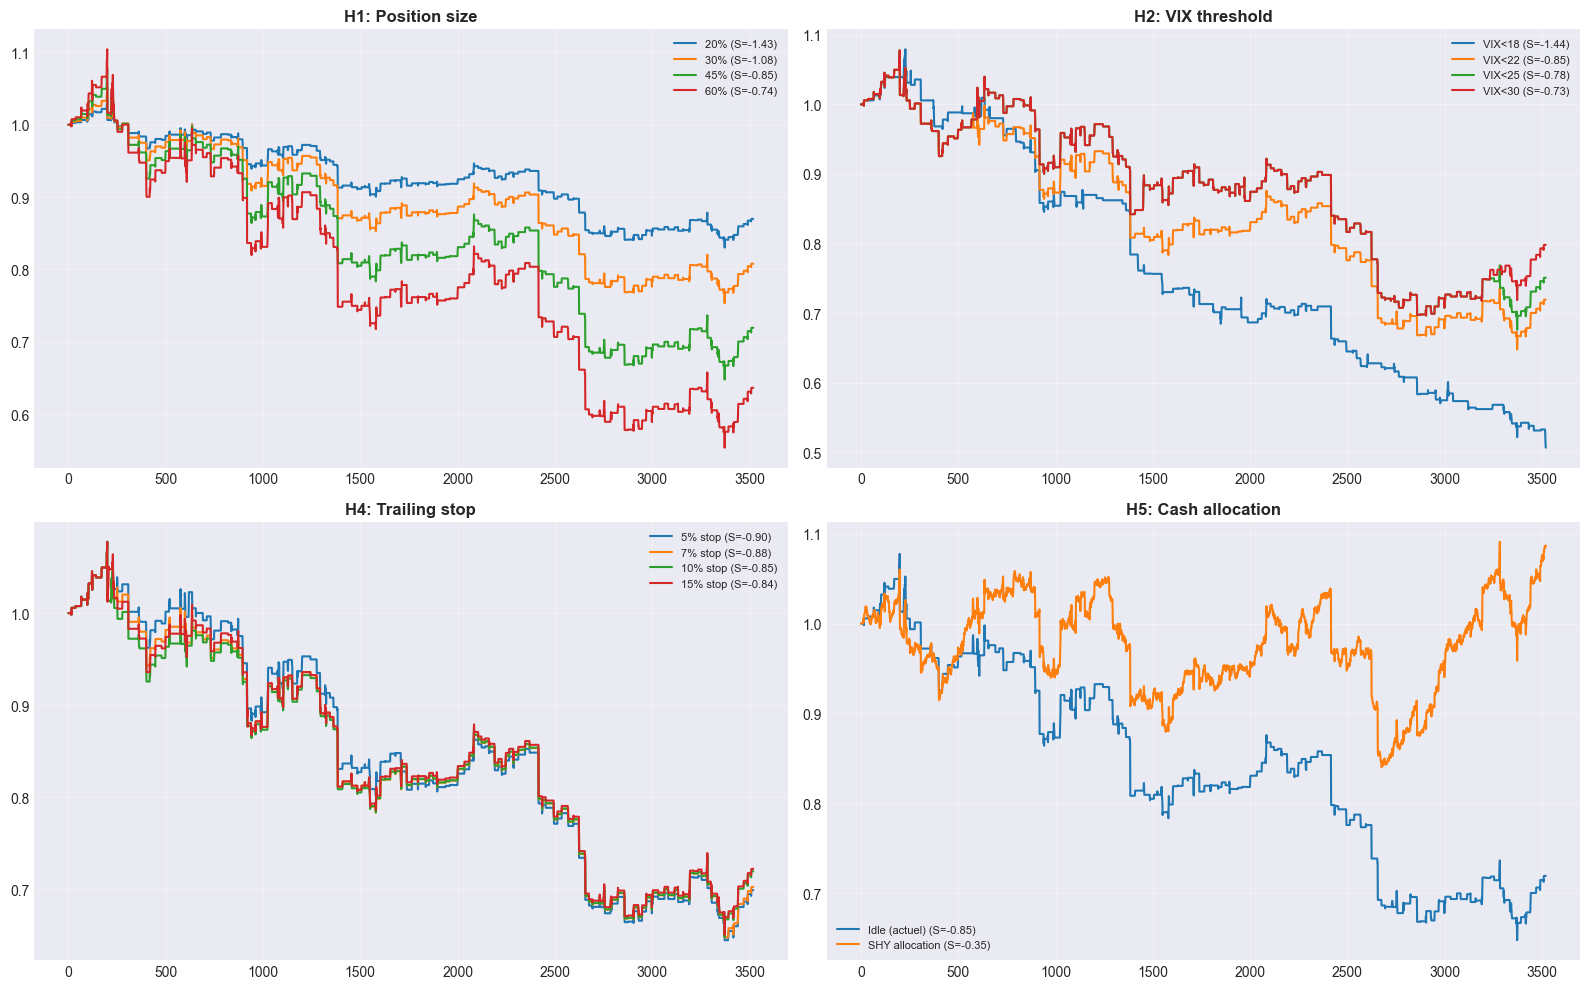

Graphique sauvegarde.


In [11]:
if not any([results_pos, results_vix, results_stop, results_cash]):
    print("No backtest results available — skipping visualization.")
    print("Run this notebook on QC Cloud with CBOE data access.")
else:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    ax = axes[0, 0]
    if results_pos:
        for name, r in results_pos.items():
            ax.plot(r['cum'].values, label=f"{name} (S={r['sharpe']:.2f})", linewidth=1.5)
    ax.set_title('H1: Position size', fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    ax = axes[0, 1]
    if results_vix:
        for name, r in results_vix.items():
            ax.plot(r['cum'].values, label=f"{name} (S={r['sharpe']:.2f})", linewidth=1.5)
    ax.set_title('H2: VIX threshold', fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    ax = axes[1, 0]
    if results_stop:
        for name, r in results_stop.items():
            ax.plot(r['cum'].values, label=f"{name} (S={r['sharpe']:.2f})", linewidth=1.5)
    ax.set_title('H4: Trailing stop', fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    ax = axes[1, 1]
    if results_cash:
        for name, r in results_cash.items():
            ax.plot(r['cum'].values, label=f"{name} (S={r['sharpe']:.2f})", linewidth=1.5)
    ax.set_title('H5: Cash allocation', fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('vix_termstructure_quantbook_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Graphique sauvegarde.")

## 10. Conclusions

### Tableau recapitulatif

| Hypothese | Résultat QuantBook | Coherent avec research.ipynb? |
|-----------|-------------------|-------------------------------|
| H1 Position size | (a remplir) | 30% recommande |
| H2 VIX threshold | (a remplir) | VIX<22 optimal |
| H3 Contango depth | (a remplir) | 1.05 standard |
| H4 Trailing stop | (a remplir) | 7% recommande |
| H5 SHY cash | (a remplir) | +2-3% CAGR attendu |

### Plafond structurel

Post-VIXplosion 2018, SVXY est passe de -1x a -0.5x.
Le premium est halve. MaxDD 35% est structural (tail events VIX).
Sharpe 0.051 reflete le fait que le risk-free rate (~3-5%) mange
presque tout le CAGR.